# Логистическая регрессия для классификации текста

## Задача классификации текста

Классификация лежит в основе многих задач NLP: определение тональности отзыва, фильтрация спама, определение языка. 
В этом занятии мы разберём несколько фундаментальных механизмов, на которых построена логистическая регрессия и, 
как следствие, современные нейронные сети.

#### Примеры задач:
- **Это спам?**
- **Кто написал Федералистские статьи?** (Гамильтон, Мэдисон, Джей)
- **Позитивный или негативный отзыв о фильме?**
- **Моделирование языка** = классификация следующего слова

**Почему не просто правила?**

Можно писать правила вручную, например:
- если есть слово *love* → позитив

Проблемы:
- не масштабируется
- много исключений
- сложно поддерживать

**Вывод:** используем машинное обучение

## Математическая модель

**Вход:**
- Набор признаков $x$
- Набор целевых значений $y$

**Выход:**
- Функция $\phi (\vec{w}, b) = w_1 \cdot x_1 + w_2 \cdot x_2 + \ldots + w_n \cdot x_n  + b$, где мы минимизируем некоторую *ошибку*.

### Пример

Задача: Предсказание дохода сотрудника

Цель: На основе возраста и опыта работы предсказать зарплату сотрудника.

In [ ]:
%conda install kagglehub

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("hussainnasirkhan/multiple-linear-regression-dataset")

print("Path to dataset files:", path)

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

In [1]:
import csv

data = []

with open("data.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append({
            "age": float(row["age"]),
            "experience": float(row["experience"]),
            "income": float(row["income"])
        })

print(data)

[{'age': 25.0, 'experience': 1.0, 'income': 30450.0}, {'age': 30.0, 'experience': 3.0, 'income': 35670.0}, {'age': 47.0, 'experience': 2.0, 'income': 31580.0}, {'age': 32.0, 'experience': 5.0, 'income': 40130.0}, {'age': 43.0, 'experience': 10.0, 'income': 47830.0}, {'age': 51.0, 'experience': 7.0, 'income': 41630.0}, {'age': 28.0, 'experience': 5.0, 'income': 41340.0}, {'age': 33.0, 'experience': 4.0, 'income': 37650.0}, {'age': 37.0, 'experience': 5.0, 'income': 40250.0}, {'age': 39.0, 'experience': 8.0, 'income': 45150.0}, {'age': 29.0, 'experience': 1.0, 'income': 27840.0}, {'age': 47.0, 'experience': 9.0, 'income': 46110.0}, {'age': 54.0, 'experience': 5.0, 'income': 36720.0}, {'age': 51.0, 'experience': 4.0, 'income': 34800.0}, {'age': 44.0, 'experience': 12.0, 'income': 51300.0}, {'age': 41.0, 'experience': 6.0, 'income': 38900.0}, {'age': 58.0, 'experience': 17.0, 'income': 63600.0}, {'age': 23.0, 'experience': 1.0, 'income': 30870.0}, {'age': 44.0, 'experience': 9.0, 'income':

In [24]:
def predict(row, w1, w2, b):
    return w1 * row["age"] + w2 * row["experience"] + b


def mse(w1, w2, b):
    total = 0.0
    n = len(data)

    for row in data:
        y_pred = predict(row, w1, w2, b)
        error = y_pred - row["income"]
        total += error * error

    return total / n

def grad_w1(w1, w2, b, h=1e-5):
    return (mse(w1 + h, w2, b) - mse(w1, w2, b)) / h

def grad_w2(w1, w2, b, h=1e-5):
    return (mse(w1, w2 + h, b) - mse(w1, w2, b)) / h

def grad_b(w1, w2, b, h=1e-5):
    return (mse(w1, w2, b + h) - mse(w1, w2, b)) / h

w1 = 0.0
w2 = 0.0
b = 0.0

learning_rate = 0.0001
epochs = 100000

for epoch in range(epochs):

    g1 = grad_w1(w1, w2, b)
    g2 = grad_w2(w1, w2, b)
    gb = grad_b(w1, w2, b)

    if epoch % 50 == 0:
        print("epoch:", epoch, "mse:", mse(w1, w2, b))
        #print("w_1:", w1)
        #print("w_2:", w2)
        #print("b:", b)

    w1 -= learning_rate * g1
    w2 -= learning_rate * g2
    b  -= learning_rate * gb

epoch: 0 mse: 1727049635.0
epoch: 50 mse: 69712739.77828258
epoch: 100 mse: 66491868.3608336
epoch: 150 mse: 63877149.56817299
epoch: 200 mse: 61752566.911713935
epoch: 250 mse: 60024311.49909792
epoch: 300 mse: 58616530.75959684
epoch: 350 mse: 57467891.67871517
epoch: 400 mse: 56528801.23777529
epoch: 450 mse: 55759159.379043736
epoch: 500 mse: 55126541.78313868
epoch: 550 mse: 54604730.67721708
epoch: 600 mse: 54172526.75901753
epoch: 650 mse: 53812788.63151653
epoch: 700 mse: 53511656.01015323
epoch: 750 mse: 53257921.67861347
epoch: 800 mse: 53042523.65194012
epoch: 850 mse: 52858134.54292466
epoch: 900 mse: 52698829.536105305
epoch: 950 mse: 52559817.91034121
epoch: 1000 mse: 52437225.95132135
epoch: 1050 mse: 52327921.422499955
epoch: 1100 mse: 52229371.63973785
epoch: 1150 mse: 52139528.696284615
epoch: 1200 mse: 52056736.68735404
epoch: 1250 mse: 51979656.660551116
epoch: 1300 mse: 51907205.94632962
epoch: 1350 mse: 51838509.10561327
epoch: 1400 mse: 51772858.250883386
epoch: 

In [30]:
def predict_income(age, experience):
    return w1 * age + w2 * experience + b

print(w1, w2, b)

print("Prediction:", predict_income(35, 5))

195.1949377823621 1941.7321044486016 20382.926304899156
Prediction: 36923.40964952484


## Переход от регрессии к классификации

В исходной задаче мы решали задачу **регрессии** — предсказывали непрерывную величину (зарплату) на основе признаков: возраста и опыта работы.

Линейная регрессионная модель имеет вид:

$$
\hat{y} = w_1 \cdot age + w_2 \cdot experience + b
$$

где:
- $\hat{y}$ — предсказанная зарплата  
- $w_1, w_2$ — веса признаков  
- $b$ — смещение  

Для обучения модели использовалась функция ошибки **MSE (Mean Squared Error)**:

$$
MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
$$

## Переход к задаче классификации

Теперь изменим постановку задачи. Вместо предсказания точного значения зарплаты будем определять **категорию сотрудника**, например:

- 0 — низкая зарплата  
- 1 — высокая зарплата  

Таким образом, задача становится задачей **бинарной классификации**.


### Математическая модель

Для решения задачи классификации используется **логистическая регрессия**.

Сначала, как и в линейной регрессии, вычисляется линейная комбинация признаков:

$$
z = w_1 \cdot age + w_2 \cdot experience + b
$$

### А как дальше?
Проблема: $z$ — не вероятность.
Решение: сигмоидная функция $\sigma(z) \in [0,1]$:
$$\sigma(z) = \frac{1}{1 + e^{-z}} = \frac{1}{1 + \exp(-z)}$$

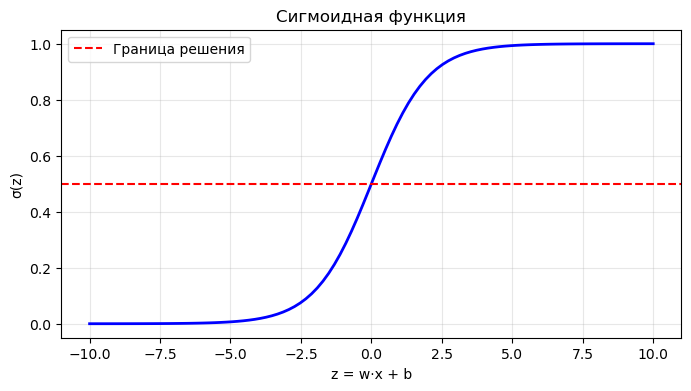

In [28]:
import numpy as np
import matplotlib.pyplot as plt

def sigmoid(z):
    """Сигмоидная функция"""
    return 1 / (1 + np.exp(-z))

# Визуализация
z = np.linspace(-10, 10, 100)
plt.figure(figsize=(8, 4))
plt.plot(z, sigmoid(z), 'b-', linewidth=2)
plt.axhline(y=0.5, color='r', linestyle='--', label='Граница решения')
plt.xlabel('z = w·x + b'); plt.ylabel('σ(z)')
plt.title('Сигмоидная функция'); plt.grid(True, alpha=0.3)
plt.legend(); plt.show()

Итого применим сигмойду и будем от 0 до 1. Сигмоидная функция:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

Итоговое предсказание:

$$
\hat{y} = \sigma(z)
$$

### И как с этим работать?
$$P(y=1|x) = \frac{P(y=1 \& x)}{P(x)} = \sigma(w \cdot x + b)$$
$$P(y=0|x) = 1 - \sigma(w \cdot x + b)$$
> Свойство: $1 - \sigma(x) = \sigma(-x)$

### Обучение: Кросс-энтропийная потеря
Цель: минимизировать расстояние между $\hat{y}$ и $y$

Вывод для одного наблюдения:
1. $p(y|x) = \hat{y}^y (1-\hat{y})^{1-y}$ (Бернулли)
2. $\log p(y|x) = y \log \hat{y} + (1-y) \log(1-\hat{y})$
3. $L_{CE} = -[y \log \hat{y} + (1-y) \log(1-\hat{y})]$

### Почему не используется MSE

MSE не подходит для классификации, потому что:
- плохо работает с вероятностями  
- приводит к медленному обучению  
- не учитывает вероятностную природу задачи  

Log Loss:
- лучше подходит для вероятностей  
- обеспечивает более стабильную сходимость  

### Сравнение задач

| Характеристика | Регрессия | Классификация |
|----------------|----------|--------------|
| Выход модели   | Число     | Вероятность (0–1) |
| Функция потерь | MSE       | Log Loss |
| Пример задачи  | Зарплата  | Класс (высокая/низкая) |

### Интерпретация результата

Значение $\hat{y}$ интерпретируется как вероятность принадлежности к классу 1:

- если $\hat{y} = 0.92$, то модель очень уверена в классе 1
- если $\hat{y} = 0.51$, то модель формально выбирает класс 1, но уверенность слабая
- если $\hat{y} = 0.08$, то модель уверена в классе 0

Обычно для принятия решения используют порог 0.5:

- если $\hat{y} \geq 0.5$ → класс 1
- если $\hat{y} < 0.5$ → класс 0

### Функция потерь

В задаче классификации используется логарифмическая функция потерь (Binary Cross-Entropy):

$$
L = -\frac{1}{n} \sum_{i=1}^{n} \left[
y_i \log(\hat{y}_i) + (1 - y_i)\log(1 - \hat{y}_i)
\right]
$$

Интуитивно эта функция работает так:

- если модель права и уверена, потеря маленькая
- если модель ошибается и ещё и уверена, потеря становится большой

### Небольшой численный пример

Пусть истинная метка $y=1$.

- если модель дала $\hat{y}=0.95$, то потеря будет мала
- если модель дала $\hat{y}=0.55$, то потеря будет заметно больше
- если модель дала $\hat{y}=0.05$, то потеря станет очень большой, потому что модель почти уверена в неправильном ответе.

### Вывод

Переход от регрессии к классификации включает:

1. Использование сигмоидной функции для получения вероятности
2. Замену функции потерь на Log Loss
3. Интерпретацию результата как класса, а не числа


## Как модель учится: пошаговый вывод градиента

Теперь перейдём к самой важной части обучения: как именно находится градиент для логистической регрессии.

Мы хотим понять, как менять веса $w$ и смещение $b$, чтобы потеря $L$ становилась меньше. Для этого нужно взять производные по параметрам.

### 1. Из чего состоит модель

Для одного наблюдения с признаками $x_1, x_2, \dots, x_n$ модель работает так:

$$
z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
$$

$$
\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}
$$

Здесь:

- $z$ — линейная комбинация признаков
- $\hat{y}$ — вероятность класса 1
- $y \in \{0, 1\}$ — истинная метка.

### 2. Функция потерь для одного объекта

Чтобы не носить сумму по всем объектам, сначала рассмотрим потерю для одного примера:

$$
L = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

Нам нужно найти $\frac{\partial L}{\partial w_j}$, то есть как потеря меняется при изменении конкретного веса.

### 3. Цепное правило

$L$ зависит от $\hat{y}$, $\hat{y}$ зависит от $z$, а $z$ зависит от $w_j$. Значит, нужно пошагово пройти эту цепочку:

$$
\frac{\partial L}{\partial w_j} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_j}
$$

Теперь найдём каждую из этих трёх частей отдельно.

### 4. Первая часть: $\frac{\partial L}{\partial \hat{y}}$

Берём производную по $\hat{y}$:

$$
L = -\left[y\log(\hat{y}) + (1-y)\log(1-\hat{y})\right]
$$

$$
\frac{\partial L}{\partial \hat{y}} = -\left[y \cdot \frac{1}{\hat{y}} + (1-y) \cdot \frac{-1}{1-\hat{y}}\right]
$$

$$
\frac{\partial L}{\partial \hat{y}} = -\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}
$$

Это первая часть цепного правила.

### 5. Вторая часть: $\frac{\partial \hat{y}}{\partial z}$

Так как $\hat{y} = \sigma(z)$, нужна производная сигмоиды:

$$
\hat{y} = \frac{1}{1 + e^{-z}} = (1 + e^{-z})^{-1}
$$

Берём производную:

$$
\frac{d\hat{y}}{dz} = -(1 + e^{-z})^{-2} \cdot (-e^{-z})
$$

$$
\frac{d\hat{y}}{dz} = \frac{e^{-z}}{(1 + e^{-z})^2}
$$

Теперь преобразуем это в более удобный вид:

$$
\frac{d\hat{y}}{dz} = \left(\frac{1}{1 + e^{-z}}\right)\left(1 - \frac{1}{1 + e^{-z}}\right)
$$

$$
\frac{d\hat{y}}{dz} = \hat{y}(1-\hat{y})
$$

### 6. Третья часть: $\frac{\partial z}{\partial w_j}$

Так как:

$$
z = w_1x_1 + w_2x_2 + \dots + w_jx_j + \dots + b
$$

то при дифференцировании по $w_j$ все другие слагаемые становятся константами, и остаётся:

$$
\frac{\partial z}{\partial w_j} = x_j
$$

А для смещения:

$$
\frac{\partial z}{\partial b} = 1
$$

### 7. Подставляем всё в цепное правило

$$
\frac{\partial L}{\partial w_j} = \left(-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right) \cdot \hat{y}(1-\hat{y}) \cdot x_j
$$

Теперь аккуратно сокращаем:

$$
\left(-\frac{y}{\hat{y}} + \frac{1-y}{1-\hat{y}}\right) \cdot \hat{y}(1-\hat{y})
$$

$$
= -y(1-\hat{y}) + (1-y)\hat{y}
$$

$$
= -y + y\hat{y} + \hat{y} - y\hat{y}
$$

$$
= \hat{y} - y
$$

Значит:

$$
\frac{\partial L}{\partial w_j} = (\hat{y} - y)x_j
$$

А для смещения, так как $\frac{\partial z}{\partial b}=1$:

$$
\frac{\partial L}{\partial b} = \hat{y} - y
$$

### 8. Почему это удобно

Итоговая формула оказалась очень простой:

$$
\frac{\partial L}{\partial w_j} = (\hat{y} - y)x_j
$$

Она хорошо интерпретируется:

- $(\hat{y} - y)$ — это ошибка модели
- $x_j$ — это сила влияния конкретного признака.

Если ошибка большая и признак активен, то вес будет меняться сильнее.

### 9. Небольшой численный пример

Пусть $x_j = 3$, $y = 1$, $\hat{y} = 0.7$.

$$
\frac{\partial L}{\partial w_j} = (0.7 - 1) \cdot 3 = -0.9
$$

Отрицательный градиент означает, что при обновлении

$$
w_j := w_j - \eta \frac{\partial L}{\partial w_j}
$$

вес будет расти, потому что модель ещё недооценивает класс 1.

Если же $y = 0$, $\hat{y} = 0.8$, $x_j = 2$, то:

$$
\frac{\partial L}{\partial w_j} = (0.8 - 0) \cdot 2 = 1.6
$$

Теперь градиент положительный, значит вес нужно уменьшать.

### 10. Итог

Главная идея такая:

1. пишем функцию потерь для одного объекта
2. берём производную по цепному правилу
3. получаем простую формулу $\frac{\partial L}{\partial w_j} = (\hat{y} - y)x_j$
4. обновляем веса в сторону, противоположную градиенту.


Поиграемся ещё раз со старой задачей: 

In [31]:
print(data)

[{'age': 25.0, 'experience': 1.0, 'income': 30450.0}, {'age': 30.0, 'experience': 3.0, 'income': 35670.0}, {'age': 47.0, 'experience': 2.0, 'income': 31580.0}, {'age': 32.0, 'experience': 5.0, 'income': 40130.0}, {'age': 43.0, 'experience': 10.0, 'income': 47830.0}, {'age': 51.0, 'experience': 7.0, 'income': 41630.0}, {'age': 28.0, 'experience': 5.0, 'income': 41340.0}, {'age': 33.0, 'experience': 4.0, 'income': 37650.0}, {'age': 37.0, 'experience': 5.0, 'income': 40250.0}, {'age': 39.0, 'experience': 8.0, 'income': 45150.0}, {'age': 29.0, 'experience': 1.0, 'income': 27840.0}, {'age': 47.0, 'experience': 9.0, 'income': 46110.0}, {'age': 54.0, 'experience': 5.0, 'income': 36720.0}, {'age': 51.0, 'experience': 4.0, 'income': 34800.0}, {'age': 44.0, 'experience': 12.0, 'income': 51300.0}, {'age': 41.0, 'experience': 6.0, 'income': 38900.0}, {'age': 58.0, 'experience': 17.0, 'income': 63600.0}, {'age': 23.0, 'experience': 1.0, 'income': 30870.0}, {'age': 44.0, 'experience': 9.0, 'income':

In [32]:
import random
import math

data_raw = data

incomes = [row["income"] for row in data_raw]
median_income = sorted(incomes)[len(incomes) // 2]

data = []

for row in data_raw:
    noise = random.randint(-10000, 10000)  # стохастичность
    noisy_income = row["income"] + noise

    label = 1 if noisy_income > median_income else 0

    data.append({
        "age": row["age"],
        "experience": row["experience"],
        "label": label
    })

print(data)

[{'age': 25.0, 'experience': 1.0, 'label': 0}, {'age': 30.0, 'experience': 3.0, 'label': 0}, {'age': 47.0, 'experience': 2.0, 'label': 0}, {'age': 32.0, 'experience': 5.0, 'label': 1}, {'age': 43.0, 'experience': 10.0, 'label': 1}, {'age': 51.0, 'experience': 7.0, 'label': 1}, {'age': 28.0, 'experience': 5.0, 'label': 1}, {'age': 33.0, 'experience': 4.0, 'label': 1}, {'age': 37.0, 'experience': 5.0, 'label': 1}, {'age': 39.0, 'experience': 8.0, 'label': 1}, {'age': 29.0, 'experience': 1.0, 'label': 0}, {'age': 47.0, 'experience': 9.0, 'label': 1}, {'age': 54.0, 'experience': 5.0, 'label': 0}, {'age': 51.0, 'experience': 4.0, 'label': 0}, {'age': 44.0, 'experience': 12.0, 'label': 1}, {'age': 41.0, 'experience': 6.0, 'label': 1}, {'age': 58.0, 'experience': 17.0, 'label': 1}, {'age': 23.0, 'experience': 1.0, 'label': 0}, {'age': 44.0, 'experience': 9.0, 'label': 1}, {'age': 37.0, 'experience': 10.0, 'label': 1}]


In [33]:
w1 = 0.0
w2 = 0.0
b = 0.0

learning_rate = 0.001
epochs = 5000

n = len(data)

def sigmoid(z):
    return 1 / (1 + math.exp(-z))


for epoch in range(epochs):

    dw1 = 0.0
    dw2 = 0.0
    db = 0.0

    loss = 0.0

    for row in data:
        x1 = row["age"]
        x2 = row["experience"]
        y = row["label"]

        # линейная часть
        z = w1 * x1 + w2 * x2 + b
        y_pred = sigmoid(z)

        # log loss (устойчивый вариант)
        y_pred = max(1e-15, min(1 - 1e-15, y_pred))
        loss += -(y * math.log(y_pred) + (1 - y) * math.log(1 - y_pred))

        # градиенты
        error = y_pred - y
        dw1 += error * x1
        dw2 += error * x2
        db += error

    # обновление весов
    w1 -= learning_rate * (1 / n) * dw1
    w2 -= learning_rate * (1 / n) * dw2
    b  -= learning_rate * (1 / n) * db

    if epoch % 500 == 0:
        print("epoch:", epoch, "loss:", loss / n)

epoch: 0 loss: 0.6931471805599453
epoch: 500 loss: 0.34927570475860253
epoch: 1000 loss: 0.26578771759113234
epoch: 1500 loss: 0.22275919335340677
epoch: 2000 loss: 0.19536268492091924
epoch: 2500 loss: 0.1759284537626703
epoch: 3000 loss: 0.16121263626776014
epoch: 3500 loss: 0.14957226623494552
epoch: 4000 loss: 0.14007161636175414
epoch: 4500 loss: 0.13213198911588153


In [ ]:

def predict(age, experience):
    z = w1 * age + w2 * experience + b
    return 1 if sigmoid(z) >= 0.5 else 0

# пример
print("Class prediction:", predict(35, 10))

Class prediction: 1


In [40]:
print(5-1e-16)

5.0


А теперь многомерная:

In [33]:
import csv
import random
import math

raw_data = []

with open("data.csv", "r") as f:
    reader = csv.DictReader(f)
    for row in reader:
        raw_data.append({
            "age": float(row["age"]),
            "experience": float(row["experience"]),
            "income": float(row["income"])
        })


def mean_std(values):
    m = sum(values) / len(values)
    var = sum((x - m) ** 2 for x in values) / len(values)
    return m, math.sqrt(var)

ages = [r["age"] for r in raw_data]
exps = [r["experience"] for r in raw_data]

age_mean, age_std = mean_std(ages)
exp_mean, exp_std = mean_std(exps)

def normalize(x, mean, std):
    return (x - mean) / (std + 1e-8)

incomes = sorted([r["income"] for r in raw_data])

q1 = incomes[len(incomes)//4]
q2 = incomes[len(incomes)//2]
q3 = incomes[(3*len(incomes))//4]

data = []

for r in raw_data:
    x1 = normalize(r["age"], age_mean, age_std)
    x2 = normalize(r["experience"], exp_mean, exp_std)

    income = r["income"]

    if income <= q1:
        label = 0
    elif income <= q2:
        label = 1
    elif income <= q3:
        label = 2
    else:
        label = 3

    data.append((x1, x2, label))


K = 4  # классы

W = [[random.uniform(-0.01, 0.01) for _ in range(2)] for _ in range(K)]
b = [0.0 for _ in range(K)]

print(W)
print(b)

def softmax(z):
    max_z = max(z)
    exp_z = [math.exp(i - max_z) for i in z]
    s = sum(exp_z)
    return [i / s for i in exp_z]

def forward(x1, x2):
    z = []
    for k in range(K):
        z_k = W[k][0] * x1 + W[k][1] * x2 + b[k]
        z.append(z_k)
    return softmax(z)

def loss():
    total = 0.0

    for x1, x2, y in data:
        p = forward(x1, x2)
        total += -math.log(p[y] + 1e-15)

    return total / len(data)

lr = 0.01
epochs = 50

for epoch in range(epochs):

    random.shuffle(data)

    for x1, x2, y in data:

        # forward
        p = forward(x1, x2)

        # gradient for softmax + cross-entropy:
        # dp_k = p_k - y_k

        for k in range(K):
            indicator = 1 if k == y else 0
            error = p[k] - indicator

            # update weights
            W[k][0] -= lr * error * x1
            W[k][1] -= lr * error * x2
            b[k]    -= lr * error

    if epoch % 5 == 0:
        print("epoch:", epoch, "loss:", loss())

def predict(age, experience):
    x1 = normalize(age, age_mean, age_std)
    x2 = normalize(experience, exp_mean, exp_std)

    p = forward(x1, x2)
    return p.index(max(p))

print("Prediction:", predict(35, 10))

[[0.009929955387678486, 0.002351306901766225], [-0.007067735728134972, 0.005001712989637128], [0.007196369433851666, -0.009895455547119552], [0.009064635707142494, 0.004204996454473959]]
[0.0, 0.0, 0.0, 0.0]
epoch: 0 loss: 1.3396745428601844
epoch: 5 loss: 1.1797082623232935
epoch: 10 loss: 1.0902764442280624
epoch: 15 loss: 1.031708080536894
epoch: 20 loss: 0.9886163567134533
epoch: 25 loss: 0.9544824179955652
epoch: 30 loss: 0.9259514282798496
epoch: 35 loss: 0.9013621162788155
epoch: 40 loss: 0.8797336294932621
epoch: 45 loss: 0.8604552702934681
Prediction: 3


## Масштабирование входных признаков (Feature Scaling)

### Зачем нужно масштабирование признаков

Когда разные признаки входных данных имеют **очень разные диапазоны значений**, это может ухудшать обучение моделей машинного обучения.

Примеры проблем:

- один признак: возраст (0–100)
- другой признак: доход (0–1 000 000)

Модель начинает "перекосно" учитывать признаки с большими значениями.


### Стандартизация (Z-score normalization)

Один из самых распространённых способов масштабирования — это стандартизация.

Она приводит данные к:

- среднему значению = 0
- стандартному отклонению = 1

#### Среднее значение признака:

$$ \mu_i = \frac{1}{m} \sum_{j=1}^{m} x_i^{(j)} $$

#### Стандартное отклонение:

$$ \sigma_i = \sqrt{\frac{1}{m} \sum_{j=1}^{m} (x_i^{(j)} - \mu_i)^2} $$


#### Преобразование (Z-score):

$$ x'_i = \frac{x_i - \mu_i}{\sigma_i} $$


#### Нормализация в диапазон [0, 1]

Альтернативный способ масштабирования — min-max нормализация:

$$ x'_i = \frac{x_i - \min(x_i)}{\max(x_i) - \min(x_i)} $$


### Зачем это нужно

Масштабирование признаков полезно, потому что:

- ускоряет градиентный спуск
- делает обучение более стабильным
- предотвращает доминирование одних признаков над другими

### Пример

Если один признак имеет значения:

- возраст: [20, 25, 30]

а другой:

- доход: [10 000, 50 000, 100 000]

без масштабирования модель будет в основном ориентироваться на доход.

### Масштабирование и нейронные сети

В больших нейронных сетях масштабирование особенно важно, потому что:

- ускоряет сходимость градиентного спуска
- уменьшает вероятность взрыва или исчезновения градиентов

### Логарифмическое масштабирование (для NLP и счётчиков)

Для текстовых данных часто используют логарифмирование.

Это связано с тем, что данные (например, частоты слов) часто имеют **Zipf-распределение**.

Пример:

- частота слов
- биграммы
- счётчики встречаемости

#### Логарифмическое преобразование:

$$ x' = \log(x + 1) $$

### Итог

Основные методы масштабирования:

- Z-score стандартизация
- Min-Max нормализация
- логарифмическое преобразование

### Вывод

Масштабирование признаков — это важный этап предобработки данных, который:

- улучшает обучение моделей
- ускоряет оптимизацию
- делает признаки сопоставимыми по масштабу

## Формулировка задачи классификации для текста

Теперь переходим к задаче классификации текста. Наша целевая переменная становится дискретной:

$$ y \in \{0, 1, ..., K\}$$

Пока для простоты:

$$ y \in \{0, 1\}$$

## Основная проблема: текст нельзя подать в модель напрямую

Модели машинного обучения работают с числами, поэтому текст необходимо преобразовать в числовое представление.

**Для этого есть куча методов:**
- Bag of Words (мешок слов)
- TF-IDF
- Word embeddings (Word2Vec, GloVe)
- Transformer embeddings

После преобразования текст становится вектором:

$$ text \rightarrow \mathbf{x} \in \mathbb{R}^n $$

## Новая модель: логистическая регрессия

Для бинарной классификации используется сигмоидная функция:

$$ p = \sigma(\mathbf{w} \cdot \mathbf{x} + b) $$

где:

- $p$ — вероятность класса 1
- $\sigma(z) = \frac{1}{1 + e^{-z}}$

### Функция потерь

В отличие от регрессии (MSE), для классификации обычно используют (Cross-Entropy Loss):

$$ L = - \left( y \log(p) + (1 - y)\log(1 - p) \right) $$

Она лучше отражает вероятностную природу задачи.

### Итоговый переход

| Регрессия | Классификация текста |
|----------|----------------------|
| income (число) | класс (0/1/…K) |
| MSE | Cross-Entropy |
| линейный выход | sigmoid / softmax |
| числовые признаки | текст → вектор |

### Вывод

Переход к классификации текстов состоит из двух ключевых шагов:

1. **Преобразование текста в числовой вектор**
2. **Замена регрессионной модели на классификационную**

Таким образом, общая схема становится:

$$ text \rightarrow vector \rightarrow model \rightarrow class $$

Это базовая идея всех современных NLP-моделей, включая нейросети и трансформеры.

## Пример: классификация тональности
Текст: *"It's hokey... the cast is great... It sucked me in"*

| Признак | Значение |
|---------|----------|
| $x_1$ = count(positive) | 3 |
| $x_2$ = count(negative) | 2 |
| $x_3$ = есть "no" | 1 |
| $x_4$ = местоимения | 3 |
| $x_5$ = есть "!" | 0 |
| $x_6$ = log(word_count) | 4.19 |

In [ ]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Данные из примера
w = np.array([2.5, 5.0, 1.2, 0.5, 2.0, 0.7])
x = np.array([3, 2, 1, 3, 0, 4.19])
b = 0.1

z = np.dot(w, x) + b
p_pos = sigmoid(z)
p_neg = 1 - p_pos

print(f"z = {z:.3f}")
print(f"P(позитивный | x) = {p_pos:.2f}")
print(f"P(негативный | x) = {p_neg:.2f}")
print(f"Предсказание: {'позитивный' if p_pos > 0.5 else 'негативный'}")

In [ ]:
def cross_entropy_loss(y_true, y_pred, eps=1e-15):
    """Кросс-энтропийная потеря"""
    y_pred = np.clip(y_pred, eps, 1-eps)
    return -(y_true * np.log(y_pred) + (1-y_true) * np.log(1-y_pred))

# Пример: p_pos = 0.70 из предыдущего расчёта
loss_correct = cross_entropy_loss(1, p_pos)  # y=1, модель права
loss_wrong = cross_entropy_loss(0, p_pos)    # y=0, модель ошибается

print(f"Потеря (модель права): {loss_correct:.2f}")
print(f"Потеря (модель ошибается): {loss_wrong:.2f}")
print("✓ Потеря меньше, когда модель права!")

## Bag of Words: как превратить текст в вектор

Логистическая регрессия не понимает строки напрямую.  
Поэтому сначала текст нужно превратить в числовые признаки.

Один из самых простых способов — **Bag of Words**.

Идея:

1. Собираем словарь всех важных слов
2. Для каждого текста считаем, сколько раз встретилось каждое слово
3. Получаем фиксированный вектор признаков

Например, если словарь такой:

$$
V = [\text{great}, \text{bad}, \text{love}, \text{boring}]
$$

то текст

> `great movie, I love it`

можно представить как вектор:

$$
[1, 0, 1, 0]
$$

Это уже обычный числовой вектор, который можно подавать в логистическую регрессию.

Такой подход особенно полезен для первых моделей в NLP: он очень простой, хорошо интерпретируется и позволяет увидеть, как отдельные слова влияют на решение модели.


In [ ]:
import re
from collections import Counter

texts = [
    "good movie with great acting",
    "bad movie and boring plot",
    "great story and good ending",
    "boring film but good music"
]

def tokenize(text):
    return re.findall(r"[a-z']+", text.lower())

vocab = sorted({token for text in texts for token in tokenize(text)})
print("Словарь:", vocab)

def vectorize(text, vocab):
    counts = Counter(tokenize(text))
    return np.array([counts.get(word, 0) for word in vocab], dtype=float)

bow_matrix = np.vstack([vectorize(text, vocab) for text in texts])

bow_df = pd.DataFrame(bow_matrix, columns=vocab, index=[f"text_{i}" for i in range(len(texts))])
bow_df

## Мини-задача: бинарная классификация тональности

Теперь соберём маленький обучающий набор.

Будем классифицировать отзывы:

- `1` — позитивный отзыв
- `0` — негативный отзыв

Важно: здесь мы не используем готовую библиотеку машинного обучения.  
Наша цель — увидеть механику логистической регрессии вручную:

- как строятся признаки
- как считается вероятность
- как считается ошибка
- как веса обновляются через градиентный спуск

Это полезно, потому что именно так устроены более сложные модели, только с большим числом признаков и параметров.


In [ ]:
train_texts = [
    "good movie",
    "great acting and good story",
    "i love this film",
    "pleasant and good",
    "bad movie",
    "boring and slow",
    "i hate this film",
    "awful boring plot"
]

y = np.array([1, 1, 1, 1, 0, 0, 0, 0], dtype=float)

vocab = sorted({token for text in train_texts for token in tokenize(text)})
X = np.vstack([vectorize(text, vocab) for text in train_texts])

print("Размер матрицы признаков:", X.shape)
pd.DataFrame(X, columns=vocab, index=[f"doc_{i}" for i in range(len(train_texts))])

In [ ]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def binary_cross_entropy(y_true, y_pred, eps=1e-15):
    y_pred = np.clip(y_pred, eps, 1 - eps)
    return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))

w = np.zeros(X.shape[1], dtype=float)
b = 0.0

learning_rate = 0.2
epochs = 400
loss_history = []

for epoch in range(epochs):
    logits = X @ w + b
    probs = sigmoid(logits)

    loss = binary_cross_entropy(y, probs)
    loss_history.append(loss)

    error = probs - y
    dw = (X.T @ error) / len(X)
    db = np.mean(error)

    w -= learning_rate * dw
    b -= learning_rate * db

    if epoch % 50 == 0:
        print(f"epoch={epoch:3d} loss={loss:.4f}")

print("\nСмещение b =", round(float(b), 4))
print("Готово: веса обучены.")

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Убывание функции потерь при обучении")
plt.xlabel("Эпоха")
plt.ylabel("Binary Cross-Entropy")
plt.grid(alpha=0.3)
plt.show()

weights_df = pd.DataFrame({
    "word": vocab,
    "weight": w
}).sort_values("weight", ascending=False)

weights_df

### Как интерпретировать веса

После обучения у каждого признака появляется вес.

- **большой положительный вес**: слово толкает модель к классу `1`
- **большой отрицательный вес**: слово толкает модель к классу `0`
- **вес около нуля**: слово почти не влияет на решение

Это одно из главных преимуществ логистической регрессии: модель легко интерпретировать.

В задачах NLP это особенно удобно:

- можно понять, какие слова считаются маркерами позитивной тональности
- какие слова чаще связаны с негативом
- какие признаки вообще бесполезны


In [ ]:
def predict_proba(text):
    x = vectorize(text, vocab)
    return float(sigmoid(x @ w + b))

test_texts = [
    "good and pleasant movie",
    "boring slow film",
    "great plot",
    "awful movie"
]

for text in test_texts:
    p = predict_proba(text)
    label = 1 if p >= 0.5 else 0
    print(f"{text!r:28s} -> p(positive)={p:.3f}, class={label}")

## Softmax: если классов больше двух

Сигмоида подходит только для **бинарной классификации**.  
Если классов больше двух, обычно используют **multinomial logistic regression** и функцию **softmax**.

Пусть у нас есть $K$ классов. Для каждого класса вычисляется свой логит:

$$
z_k = w_k \cdot x + b_k
$$

После этого логиты превращаются в вероятности:

$$
P(y=k \mid x) = \frac{e^{z_k}}{\sum_{j=1}^{K} e^{z_j}}
$$

Свойства softmax:

- все вероятности лежат в диапазоне $[0, 1]$
- сумма вероятностей по всем классам равна 1
- класс с максимальной вероятностью становится предсказанием модели

В NLP это нужно, например, когда мы различаем:

- `sports`
- `politics`
- `tech`

или несколько языков, авторов, тематик и т.д.


In [ ]:
multi_texts = [
    "team won the match",
    "great game and goal",
    "government passed the law",
    "election and political debate",
    "new software release",
    "computer and modern technology"
]

multi_labels = np.array([0, 0, 1, 1, 2, 2])
label_names = {0: "sports", 1: "politics", 2: "tech"}

multi_vocab = sorted({token for text in multi_texts for token in tokenize(text)})
X_multi = np.vstack([vectorize(text, multi_vocab) for text in multi_texts])

def softmax(logits):
    logits = logits - np.max(logits, axis=1, keepdims=True)
    exp_logits = np.exp(logits)
    return exp_logits / np.sum(exp_logits, axis=1, keepdims=True)

K = len(label_names)
Y_multi = np.eye(K)[multi_labels]

W = np.zeros((X_multi.shape[1], K), dtype=float)
b_multi = np.zeros(K, dtype=float)

learning_rate = 0.3
epochs = 500
multi_loss_history = []

for epoch in range(epochs):
    logits = X_multi @ W + b_multi
    probs = softmax(logits)

    loss = -np.mean(np.sum(Y_multi * np.log(np.clip(probs, 1e-15, 1.0)), axis=1))
    multi_loss_history.append(loss)

    error = probs - Y_multi
    dW = (X_multi.T @ error) / len(X_multi)
    db = np.mean(error, axis=0)

    W -= learning_rate * dW
    b_multi -= learning_rate * db

    if epoch % 100 == 0:
        print(f"epoch={epoch:3d} loss={loss:.4f}")

print("Сумма вероятностей в каждой строке:")
print(np.sum(softmax(X_multi @ W + b_multi), axis=1))

In [ ]:
def predict_multiclass(text):
    x = vectorize(text, multi_vocab)
    probs = softmax((x.reshape(1, -1) @ W + b_multi.reshape(1, -1)))
    pred = int(np.argmax(probs))
    return probs[0], pred

examples = [
    "the team scored a goal",
    "parliament discussed the law",
    "new computer software"
]

for text in examples:
    probs, pred = predict_multiclass(text)
    readable = {label_names[i]: round(float(probs[i]), 3) for i in range(K)}
    print(text)
    print(" probabilities:", readable)
    print(" predicted class:", label_names[pred])
    print()

## Как оценивать модель

Одна только accuracy не всегда достаточна.

Для задач классификации часто используют:

- **Accuracy** — доля правильных ответов
- **Precision** — насколько "чистыми" были положительные предсказания
- **Recall** — насколько хорошо нашли все реальные положительные объекты
- **F1-score** — баланс между precision и recall

Это особенно важно в NLP:

- в спам-фильтрации
- в классификации токсичности
- в медицинских и юридических текстах

Например, если модель почти никогда не предсказывает спам, accuracy может быть высокой, но recall для спама будет плохим.


In [ ]:
train_probs = sigmoid(X @ w + b)
train_pred = (train_probs >= 0.5).astype(int)
y_true = y.astype(int)

tp = int(np.sum((train_pred == 1) & (y_true == 1)))
tn = int(np.sum((train_pred == 0) & (y_true == 0)))
fp = int(np.sum((train_pred == 1) & (y_true == 0)))
fn = int(np.sum((train_pred == 0) & (y_true == 1)))

accuracy = (tp + tn) / len(y_true)
precision = tp / (tp + fp + 1e-15)
recall = tp / (tp + fn + 1e-15)
f1 = 2 * precision * recall / (precision + recall + 1e-15)

print("Confusion matrix")
print(np.array([[tn, fp],
                [fn, tp]]))
print()
print(f"accuracy  = {accuracy:.3f}")
print(f"precision = {precision:.3f}")
print(f"recall    = {recall:.3f}")
print(f"f1-score  = {f1:.3f}")

## Регуляризация: как бороться с переобучением

Если модель слишком сильно подстраивается под обучающие данные, возникает **overfitting**.

Один из основных способов борьбы с этим — **регуляризация**.

### L2-регуляризация

В функцию потерь добавляют штраф за слишком большие веса:

$$
L_{new} = L_{CE} + \lambda \sum_{j=1}^{n} w_j^2
$$

Что это даёт:

- веса становятся более "осторожными"
- модель меньше запоминает шум
- обобщение на новых данных обычно улучшается

### L1-регуляризация

Ещё один вариант:

$$
L_{new} = L_{CE} + \lambda \sum_{j=1}^{n} |w_j|
$$

L1 часто делает веса более разреженными: часть из них становится ровно нулевой.  
Это удобно, когда хочется автоматически отбирать наиболее важные признаки.


In [ ]:
w_plain = np.array([3.0, -2.0, 0.5, 4.0])
w_small = np.array([1.2, -0.8, 0.2, 1.1])

l1_plain = np.sum(np.abs(w_plain))
l1_small = np.sum(np.abs(w_small))

l2_plain = np.sum(w_plain ** 2)
l2_small = np.sum(w_small ** 2)

print("Без регуляризации модель может получить большие веса.")
print("Пример 1:", w_plain)
print("Пример 2:", w_small)
print()
print(f"L1 штраф для примера 1: {l1_plain:.2f}")
print(f"L1 штраф для примера 2: {l1_small:.2f}")
print(f"L2 штраф для примера 1: {l2_plain:.2f}")
print(f"L2 штраф для примера 2: {l2_small:.2f}")

## Что важно запомнить по главе

Логистическая регрессия для NLP строится вокруг нескольких идей:

1. **Текст нужно превратить в признаки**  
   Самый базовый вариант — Bag of Words.

2. **Для двух классов используется сигмоида**  
   Она переводит логит $z = w \cdot x + b$ в вероятность.

3. **Для нескольких классов используется softmax**  
   Он превращает набор логитов в распределение вероятностей по классам.

4. **Обучение идёт через кросс-энтропию и градиентный спуск**  
   Именно это позволяет подбирать веса автоматически.

5. **Веса можно интерпретировать**  
   По ним видно, какие слова помогают модели принять решение.

6. **Нужны метрики и регуляризация**  
   Они помогают честно оценивать качество модели и бороться с переобучением.

Логистическая регрессия — это одна из самых простых, но очень важных моделей в NLP.  
Через неё удобно понять фундамент почти всех более сложных нейросетевых классификаторов.


## Визуализации для новых блоков

Чтобы конспект был более наглядным, построим несколько графиков:

- какие слова сильнее всего тянут модель в позитив или негатив
- как убывает ошибка в многоклассовой модели
- как `softmax` распределяет вероятности между классами
- как выглядит confusion matrix


In [ ]:
top_n = min(6, len(weights_df))
top_positive = weights_df.head(top_n).sort_values("weight")
top_negative = weights_df.tail(top_n).sort_values("weight")

plt.figure(figsize=(10, 5))
plt.barh(top_positive["word"], top_positive["weight"], color="seagreen", alpha=0.8, label="позитивные маркеры")
plt.barh(top_negative["word"], top_negative["weight"], color="indianred", alpha=0.8, label="негативные маркеры")
plt.axvline(0, color="black", linewidth=1)
plt.title("Какие слова сильнее всего влияют на решение модели")
plt.xlabel("Вес признака")
plt.ylabel("Слово")
plt.legend()
plt.grid(axis="x", alpha=0.3)
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(multi_loss_history, color="darkorange", linewidth=2)
plt.title("Убывание ошибки в многоклассовой логистической регрессии")
plt.xlabel("Эпоха")
plt.ylabel("Cross-Entropy Loss")
plt.grid(alpha=0.3)
plt.show()

In [ ]:
sample_text = "the team scored a goal"
sample_probs, sample_pred = predict_multiclass(sample_text)

plt.figure(figsize=(7, 4))
plt.bar(label_names.values(), sample_probs, color=["steelblue", "tomato", "goldenrod"])
plt.ylim(0, 1)
plt.title(f"Softmax-вероятности для: {sample_text!r}")
plt.ylabel("Вероятность")
plt.grid(axis="y", alpha=0.3)
plt.show()

print("Предсказанный класс:", label_names[sample_pred])

In [ ]:
cm = np.array([[tn, fp],
               [fn, tp]])

plt.figure(figsize=(5, 4))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xticks([0, 1], ["pred 0", "pred 1"])
plt.yticks([0, 1], ["true 0", "true 1"])

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black", fontsize=12)

plt.colorbar()
plt.tight_layout()
plt.show()

## ??? ???????? `@` ? Python

????? ? ???? ??????????? ?????? ????:

```python
z = X @ w + b
```

?????? `@` ???????? **????????? ?????????**.

? ??????? ????????? ???????? ??? ????? ??????, ?????? ??? ?????? ????? ?????? ??????? ???????? ?????????? ?????????.

???? ???????? ??????? ???????, ?? ??? ?????? ??????? ???:

$$
z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n
$$

? ? ?????????? ????????? ?????? ??? ???:

$$
z = x @ w
$$

???? ???????? ?????, ?? ?????? ?????? ??????? `x` ????? ??????? `X`, ? ?????:

$$
z = X @ w
$$

?? ???? ???????? `@` ???????? ????? ????????? ????????? ??? ???? ????????.

?????:

- `*` ? `numpy` ?????? ???????? **???????????? ?????????**
- `@` ???????? **????????? ?????????**


In [ ]:
a = np.array([1, 2, 3])
b = np.array([10, 20, 30])

print('a * b =', a * b)
print('a @ b =', a @ b)

? ???? ???????:

- `a * b` ???????? ???????? ?? ????????: `[10, 40, 90]`
- `a @ b` ??????? ????? ????????????:

$$
1 \cdot 10 + 2 \cdot 20 + 3 \cdot 30 = 140
$$

??? ??? ???? ?????, ? ?? ??????.


In [ ]:
X_demo = np.array([
    [1, 2],
    [3, 4],
    [5, 6]
], dtype=float)

w_demo = np.array([0.5, -1.0], dtype=float)
b_demo = 0.2

print('X_demo:')
print(X_demo)
print()
print('w_demo:')
print(w_demo)
print()

print('X_demo @ w_demo =')
print(X_demo @ w_demo)
print()
print('X_demo @ w_demo + b_demo =')
print(X_demo @ w_demo + b_demo)

??? ??? ??????:

- ?????? ?????? `X_demo` ? ????????? ??????
- `w_demo` ? ???? ?????????
- `X_demo @ w_demo` ? ?????? ??? ???? ???????? ?????

?? ???? Python ????????????? ???????:

$$
z_1 = 1 \cdot 0.5 + 2 \cdot (-1.0)
$$

$$
z_2 = 3 \cdot 0.5 + 4 \cdot (-1.0)
$$

$$
z_3 = 5 \cdot 0.5 + 6 \cdot (-1.0)
$$

? ????? ?? ????????? ???????? `b_demo`.

?????? ??????? ?????? `X @ w + b` ??? ????? ??????????? ? ????????????? ?????????, ????????? ????? ? ?????? ? ???????? ??????? ??? ML.
